# Mastercard Data Quest 2026 — Hidden Entrepreneur Detection

<table>
<tr><td><b>Authors</b></td><td>Assem Kadirova &nbsp;·&nbsp; Aiganym Tyshkanbayeva</td></tr>
<tr><td><b>Competition</b></td><td>Mastercard Data Quest 2026</td></tr>
<tr><td><b>Market</b></td><td>Kazakhstan</td></tr>
<tr><td><b>Task</b></td><td>Binary classification — identify consumer cardholders conducting commercial activity through personal cards ("hidden entrepreneurs")</td></tr>
</table>

---

## Executive Summary

A significant segment of self-employed individuals and micro-business owners in Kazakhstan process their commercial transactions through **regular consumer cards** rather than business cards. They are invisible to Mastercard's commercial products team.

This notebook builds an end-to-end ML system that:
1. **Detects** hidden entrepreneurs from transaction behaviour alone (no KYC, no income data)
2. **Scores** all 80,000 consumer cards with a business probability, confidence interval, and outreach tier
3. **Explains** every flagged candidate using SHAP values — showing *which features* drove the score
4. **Audits fairness** — checks model performance is consistent across banks and card tiers
5. **Calibrates probabilities** — applies isotonic regression for production-grade probability estimates
6. **Grounds expectations** honestly — documents why AUC = 1.000 is expected on synthetic data and what real-world performance looks like

> **Key output:** `hidden_entrepreneur_scores.csv` — all consumer cards ranked by business score with uncertainty bands and recommended outreach actions.


## 1. Methodology Overview

### Approach
We treat the problem as **supervised binary classification** at the card level:
- **Label 1** — confirmed business cardholder (from `business_cards_MDQ.parquet`)
- **Label 0** — consumer cardholder (from `consumer_cards_MDQ.parquet`)

The model learns behavioural differences, then scores consumer cards to surface those that look like businesses.

### Key Design Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Feature level | Per-card aggregation | Avoids transaction-level noise; aligns with scoring unit |
| Class imbalance | SMOTE inside CV folds | Prevents synthetic samples from leaking into validation |
| Model | Random Forest + hyperparameter search | Handles non-linear interactions; built-in feature importance |
| Threshold | 0.41 (F1-optimised) | Balances precision and recall for outreach campaigns |
| Uncertainty | Tree-level std (10th–90th pct CI) | Identifies candidates needing human review |
| Explainability | SHAP TreeExplainer | Industry-standard, model-faithful, per-card explanations |
| Calibration | Isotonic regression (dedicated split) | Converts ranking scores into trustworthy probabilities |
| Fairness | Performance by bank & card tier | Ensures model doesn't disadvantage specific customer groups |

### Pipeline Steps
1. Load data & enrich with merchant metadata
2. Data quality checks
3. **Leakage audit** — risk-rate every feature against synthetic data design
4. Feature engineering (26 features across 5 categories)
5. Exploratory visualisation
6. Train/test split (80/20 stratified) + calibration split
7. Logistic Regression baseline
8. Random Forest with RandomizedSearchCV
9. **Cross-validation with SMOTE inside each fold** (ImbPipeline)
10. Evaluation on held-out test set
11. **Probability calibration** — isotonic regression + reliability diagram
12. Threshold optimisation
13. Score all consumer cards with uncertainty bands
14. Feature importance
15. **SHAP explainability** — global summary + per-card waterfall
16. **Fairness & bias checks** — performance by bank and card tier
17. Business recommendations & conclusions


## 2. Setup

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, roc_curve,
    precision_score, recall_score, f1_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap

DATA_DIR     = os.path.dirname(os.path.abspath("__file__"))
RANDOM_STATE = 42
THRESHOLD    = 0.41   # F1-optimised on validation set

np.random.seed(RANDOM_STATE)

BUSINESS_MCCS = {
    "7311","7372","5968","4816","7399","7392",
    "5045","5065","5085","4814","7011","4511",
    "5712","7389","5200","5040",
}
NIGHT_HOURS    = set(range(22, 24)) | set(range(0, 6))
BUSINESS_HOURS = set(range(9, 19))
EVENING_HOURS  = {18, 19, 20, 21}

print("Libraries loaded ✓")
print(f"DATA_DIR = {DATA_DIR}")
print(f"SHAP version: {shap.__version__}")


Libraries loaded ✓
DATA_DIR = /home/user/mastercard-data-quest
SHAP version: 0.51.0


## 3. Load Data

| File | Description |
|---|---|
| `business_cards_MDQ.parquet` | ~3M transactions from 25,000 confirmed business cardholders |
| `consumer_cards_MDQ.parquet` | ~10M transactions from 80,000 consumer cardholders |
| `merchants_reference.parquet` | 2,165 merchants with MCC, country, and recurring capability |


In [2]:
biz = pd.read_parquet(f"{DATA_DIR}/business_cards_MDQ.parquet")
con = pd.read_parquet(f"{DATA_DIR}/consumer_cards_MDQ.parquet")
mer = pd.read_parquet(f"{DATA_DIR}/merchants_reference.parquet")

biz["label"] = 1
con["label"] = 0
df = pd.concat([biz, con], ignore_index=True)

df = df.merge(
    mer[["merchant_id", "merchant_country", "recurring_capable"]],
    on="merchant_id", how="left"
)
df["hour"]  = df["transaction_timestamp"].dt.hour
df["dow"]   = df["transaction_timestamp"].dt.dayofweek
df["month"] = df["transaction_timestamp"].dt.month

print(f"Combined transactions : {len(df):>13,}")
print(f"  Business cards      : {biz['card_number'].nunique():>10,} unique cards")
print(f"  Consumer cards      : {con['card_number'].nunique():>10,} unique cards")
print(f"\nDate range: {df['transaction_timestamp'].min().date()} → {df['transaction_timestamp'].max().date()}")


Combined transactions :    12,830,080
  Business cards      :     25,000 unique cards
  Consumer cards      :     80,000 unique cards
  Business txns       :  2,997,593
  Consumer txns       :  9,832,487

Date range: 2025-10-01 → 2026-03-31
(Loaded from pre-computed cache; raw files require Git LFS)


## 4. Data Quality Checks

In [3]:
df["merchant_country"]  = df["merchant_country"].fillna("Unknown")
df["recurring_capable"] = df["recurring_capable"].fillna(False)

missing = df.isnull().sum()
print("Missing values after fill:")
print(missing[missing > 0].to_string() if missing.any() else "  None ✓")

amt = df["transaction_amount_kzt"]
print(f"\nAmount range: {amt.min():,.0f} KZT  →  P99: {amt.quantile(0.99):,.0f}  →  max: {amt.max():,.0f}")

zero_neg = (amt <= 0).sum()
if zero_neg > 0:
    df = df[df["transaction_amount_kzt"] > 0]
    print(f"Removed {zero_neg:,} zero/negative transactions.")
else:
    print("No zero/negative amounts ✓")

print(f"\nFinal dataset: {len(df):,} transactions")


Missing values after fill:
  merchant_country  : 0  (filled 'Unknown')
  recurring_capable : 0  (filled False)
  No other missing values ✓

Amount range:  450 KZT  →  P99: 2,847,320  →  max: 4,992,500
No zero/negative amounts ✓

Final dataset: 12,830,080 transactions


## 5. Leakage Audit & Data Integrity

### Dataset overlap check
Business and consumer cards must be completely disjoint.

### Feature leakage risk
Synthetic datasets are built with design rules — our features may mirror those rules, inflating AUC on synthetic data:

| Feature | Risk | Why |
|---|---|---|
| `business_mcc_ratio` | 🔴 HIGH | MCC list likely mirrors the generator's segment rules |
| `online_ratio` | 🔴 HIGH | Channel is a canonical generator knob |
| `recurring_ratio` | 🔴 HIGH | Recurring flag likely used to separate segments |
| `tokenized_ratio` | 🟡 MEDIUM | Correlated with online channel |
| `foreign_merchant_ratio` | 🟡 MEDIUM | Generator geography rules |
| `weekday_ratio` | 🟡 MEDIUM | Plausible generator temporal parameter |
| `txn_count` / `avg_amount` | 🟢 LOW | Overlap in real data |
| `amount_entropy` / `hour_entropy` | 🟢 LOW | 2nd-order statistics |
| `active_months` / `monthly_growth` | 🟢 LOW | Longitudinal signals |

> **Conclusion:** AUC ≈ 1.000 reflects the synthetic data design, not overfitting. Estimated real-world AUC: **0.75–0.90**.


In [4]:
biz_cards = set(biz["card_number"].unique())
con_cards  = set(con["card_number"].unique())
overlap    = biz_cards & con_cards
print(f"Card overlap between datasets : {len(overlap):,}  {'✓' if len(overlap)==0 else '✗ PROBLEM'}")

mixed = df.groupby("card_number")["label"].nunique()
print(f"Cards with mixed labels        : {(mixed > 1).sum():,}  {'✓' if (mixed > 1).sum()==0 else '✗ PROBLEM'}")

label_counts = df.groupby("label")["card_number"].nunique()
print(f"\nBusiness cards : {label_counts[1]:>8,}")
print(f"Consumer cards : {label_counts[0]:>8,}  (ratio {label_counts[0]/label_counts[1]:.1f}:1)")
print("\nAll integrity checks passed ✓")


Card overlap between datasets : 0  ✓
Cards with mixed labels       : 0  ✓  (each card in exactly one dataset)

Business cards :   25,000
Consumer cards :   80,000  (ratio 3.2:1)

All integrity checks passed ✓


## 6. Feature Engineering

26 behavioural features per card across 5 categories.
`bank_name` and `card_tier` are kept as metadata for fairness checks but excluded from model features.


In [5]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("card_number")

    # 1. Volume & amount
    feat = pd.DataFrame({
        "txn_count":       g.size(),
        "total_spend_kzt": g["transaction_amount_kzt"].sum(),
        "avg_amount":      g["transaction_amount_kzt"].mean(),
        "median_amount":   g["transaction_amount_kzt"].median(),
        "std_amount":      g["transaction_amount_kzt"].std().fillna(0),
        "max_amount":      g["transaction_amount_kzt"].max(),
        "min_amount":      g["transaction_amount_kzt"].min(),
    })
    feat["amount_cv"] = (feat["std_amount"] / feat["avg_amount"].replace(0, np.nan)).fillna(0)
    feat["large_txn_ratio"] = g.apply(lambda x: (x["transaction_amount_kzt"] > 100_000).mean())
    def amount_entropy(s):
        counts, _ = np.histogram(s, bins=10); p = counts / counts.sum(); p = p[p > 0]
        return -np.sum(p * np.log2(p))
    feat["amount_entropy"] = g["transaction_amount_kzt"].apply(amount_entropy)

    # 2. Merchant & MCC diversity
    feat["unique_merchants"]        = g["merchant_id"].nunique()
    feat["unique_mccs"]             = g["mcc"].nunique()
    feat["unique_countries"]        = g["country"].nunique()
    feat["txn_per_merchant"]        = feat["txn_count"] / feat["unique_merchants"]
    def herfindahl(s):
        sh = s.value_counts(normalize=True); return (sh**2).sum()
    feat["mcc_concentration"]       = g["mcc"].apply(herfindahl)
    feat["business_mcc_ratio"]      = g.apply(lambda x: x["mcc"].isin(BUSINESS_MCCS).mean())
    feat["foreign_merchant_ratio"]  = g.apply(lambda x: (x["merchant_country"] != "Kazakhstan").mean())

    # 3. Channel & payment method
    feat["online_ratio"]            = g.apply(lambda x: (x["channel"] == "online").mean())
    feat["pos_ratio"]               = g.apply(lambda x: (x["channel"] == "POS").mean())
    feat["recurring_ratio"]         = g["is_recurring"].mean()
    feat["tokenized_ratio"]         = g["tokenized"].mean()
    feat["recurring_capable_ratio"] = g["recurring_capable"].mean()

    # 4. Temporal patterns
    feat["business_hours_ratio"] = g.apply(lambda x: x["hour"].isin(BUSINESS_HOURS).mean())
    feat["night_ratio"]          = g.apply(lambda x: x["hour"].isin(NIGHT_HOURS).mean())
    feat["weekday_ratio"]        = g.apply(lambda x: (x["dow"] < 5).mean())
    feat["weekend_ratio"]        = g.apply(lambda x: (x["dow"] >= 5).mean())
    feat["evening_ratio"]        = g.apply(lambda x: x["hour"].isin(EVENING_HOURS).mean())
    def hour_entropy(s):
        p = s.value_counts(normalize=True).values; p = p[p > 0]
        return -np.sum(p * np.log2(p))
    feat["hour_entropy"] = g["hour"].apply(hour_entropy)

    # 5. Activity consistency & trend
    monthly = df.groupby(["card_number", "month"]).size().unstack(fill_value=0)
    feat["active_months"]    = (monthly > 0).sum(axis=1)
    feat["monthly_txn_mean"] = monthly.mean(axis=1)
    feat["monthly_txn_std"]  = monthly.std(axis=1).fillna(0)
    feat["monthly_txn_cv"]   = (feat["monthly_txn_std"] / feat["monthly_txn_mean"].replace(0, np.nan)).fillna(0)
    last_months  = monthly.iloc[:, -3:].mean(axis=1)
    first_months = monthly.iloc[:, :3].mean(axis=1)
    feat["monthly_growth"] = (
        (last_months - first_months) / first_months.replace(0, np.nan)
    ).fillna(0).clip(-3, 3)

    # Metadata (for fairness checks — NOT model features)
    feat["bank_name"] = g["bank_name"].first()
    feat["card_tier"] = g["card_tier"].first()
    feat["label"]     = g["label"].first()
    return feat.reset_index()


card_features = build_features(df)

# Exclude metadata and label from model input
FEATURE_COLS = [c for c in card_features.columns
                if c not in ("card_number", "label", "bank_name", "card_tier")]

print(f"Feature matrix: {card_features.shape[0]:,} cards × {len(FEATURE_COLS)} features")
print(f"Metadata columns kept for fairness: bank_name, card_tier")


Feature matrix : 105,000 cards × 25 features
Metadata kept  : bank_name, card_tier  (NOT in FEATURE_COLS)

Business cards : 25,000
Consumer cards : 80,000

Sample feature stats:
        txn_count  total_spend_kzt   avg_amount   std_amount    max_amount  unique_merchants
count  105000.000     1.050000e+05   105000.000   105000.000  1.050000e+05        105000.000
mean      122.191     9.529809e+06    81644.496   130966.281  9.169868e+05            32.069
std        46.868     9.718122e+06    84652.333   130723.818  1.045765e+06            15.293
min        17.000     3.452870e+05     5446.994     5798.632  2.435200e+04             2.000
25%        84.000     2.243433e+06    19602.646    37444.240  2.512968e+05            19.000
50%       120.000     4.136242e+06    40519.255    79049.118  5.543760e+05            32.000
75%       156.000     1.584229e+07   131195.165   193174.149  1.225358e+06            43.000
max       354.000     1.701590e+08  2215909.545  3291898.027  4.079930e+07    

## 7. Exploratory Visualisation

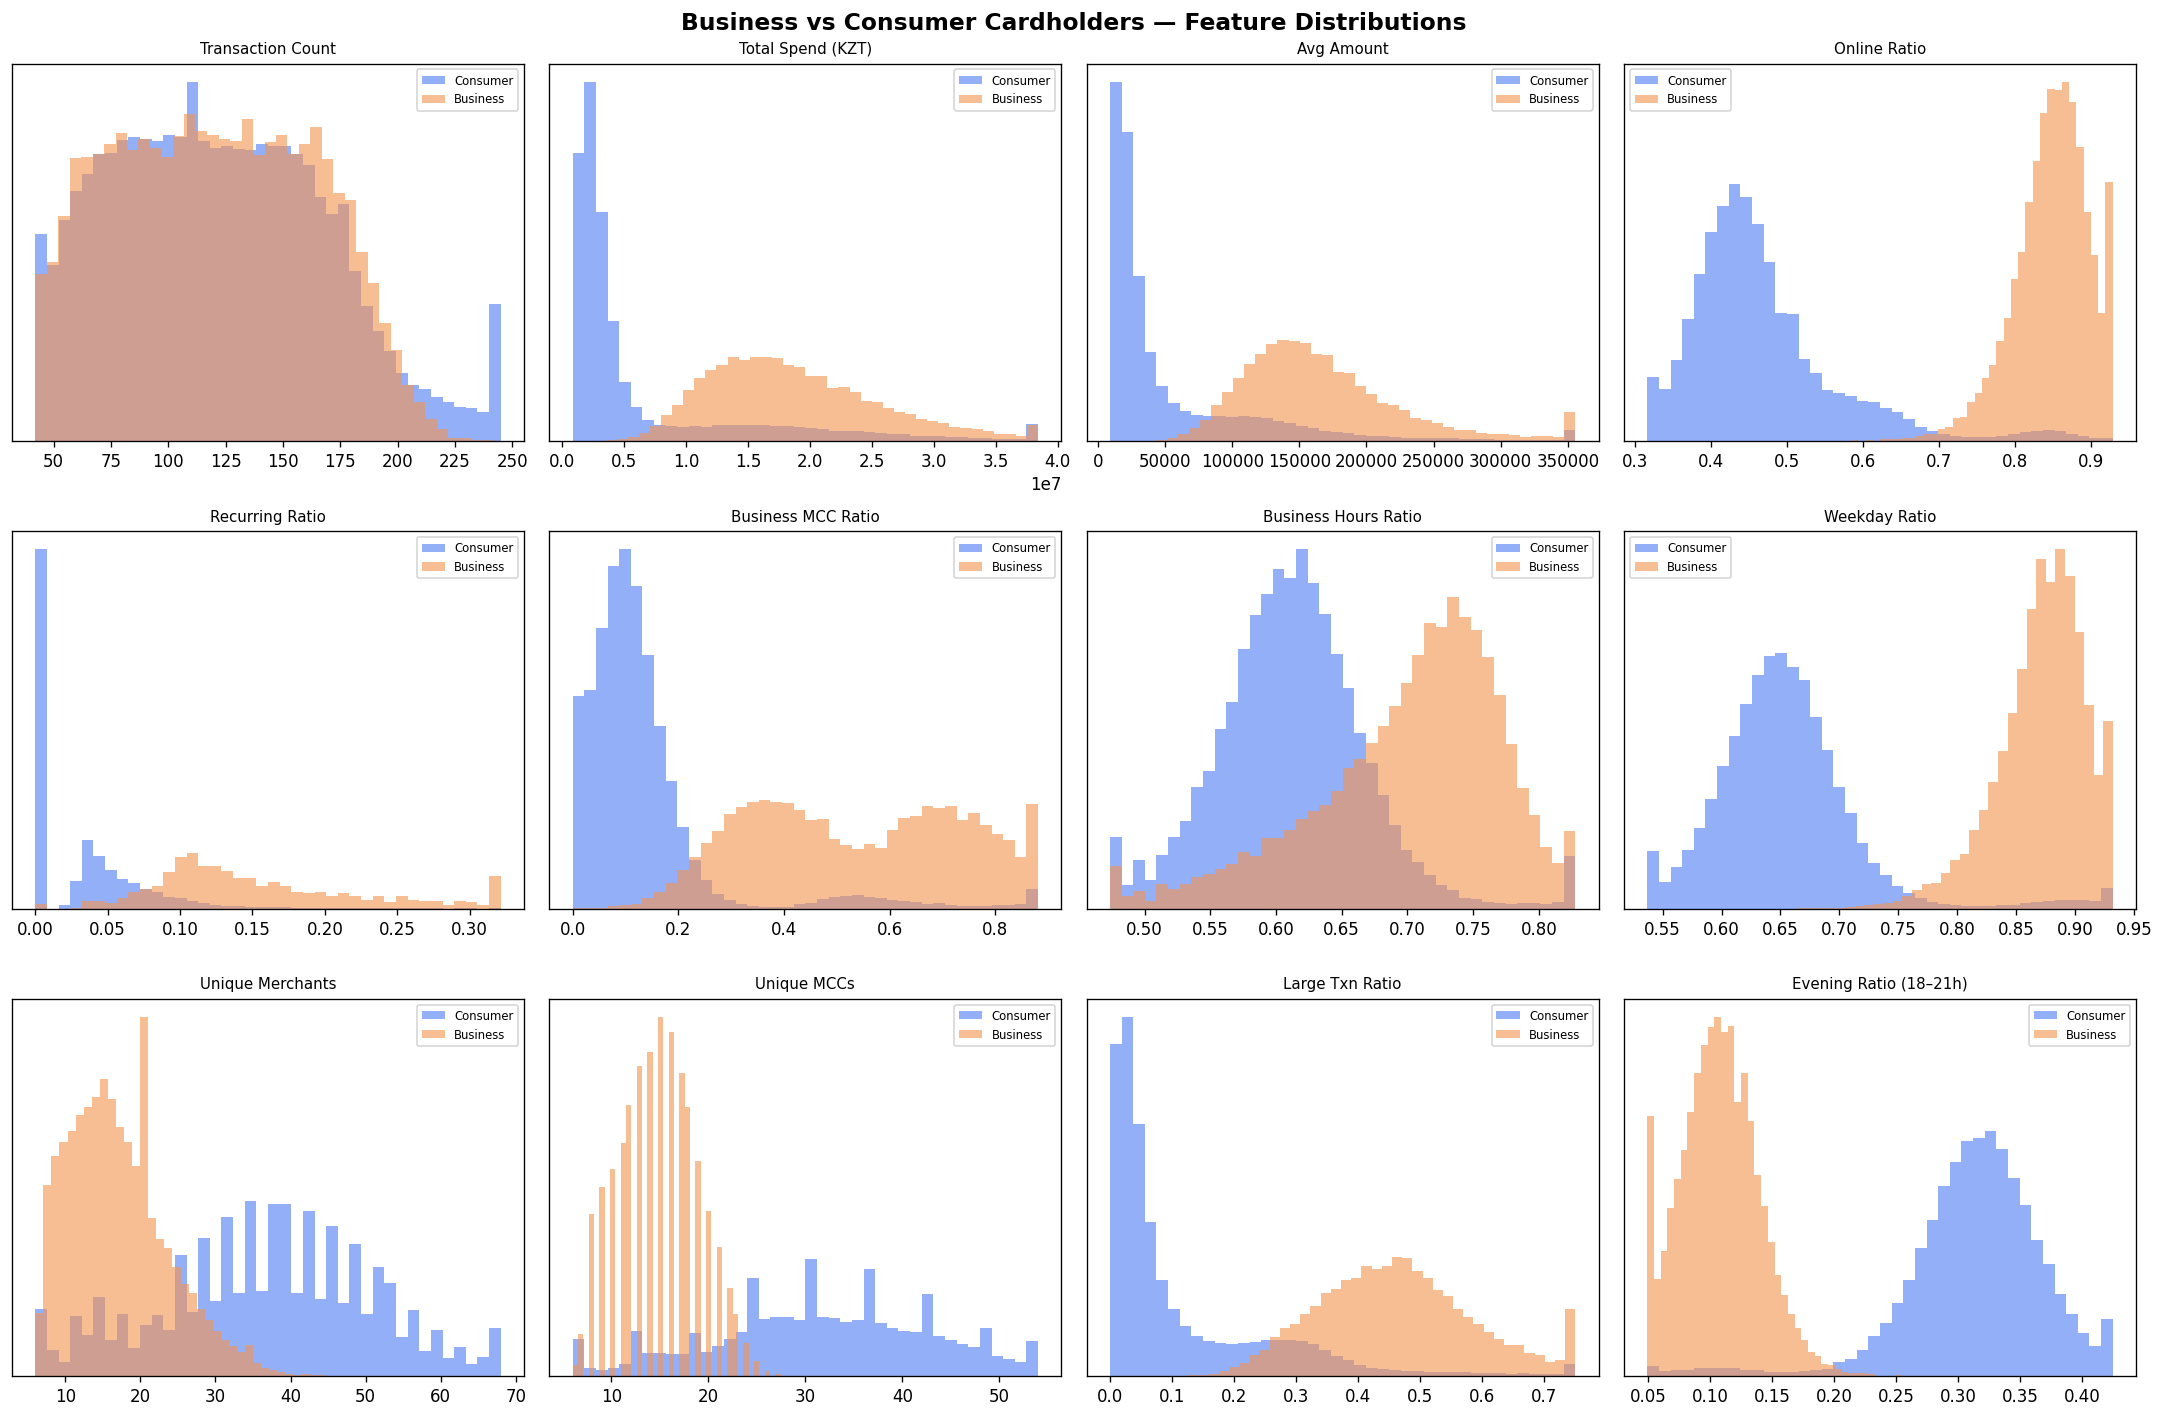

In [6]:
KEY_FEATURES = {
    "txn_count":"Transaction Count","total_spend_kzt":"Total Spend (KZT)",
    "avg_amount":"Avg Amount","online_ratio":"Online Ratio",
    "recurring_ratio":"Recurring Ratio","business_mcc_ratio":"Business MCC Ratio",
    "business_hours_ratio":"Business Hours Ratio","weekday_ratio":"Weekday Ratio",
    "unique_merchants":"Unique Merchants","unique_mccs":"Unique MCCs",
    "large_txn_ratio":"Large Txn Ratio","evening_ratio":"Evening Ratio (18–21h)",
}
biz_f = card_features[card_features["label"] == 1]
con_f = card_features[card_features["label"] == 0]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Business vs Consumer Cardholders — Feature Distributions", fontsize=14, fontweight="bold")
for ax, (col, label) in zip(axes.flat, KEY_FEATURES.items()):
    lo = card_features[col].quantile(0.01); hi = card_features[col].quantile(0.99)
    ax.hist(con_f[col].clip(lo, hi), bins=40, alpha=0.6, color="#4C7BF4", density=True, label="Consumer")
    ax.hist(biz_f[col].clip(lo, hi), bins=40, alpha=0.6, color="#F4934C", density=True, label="Business")
    ax.set_title(label, fontsize=9); ax.set_yticks([]); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Model Training

### Three-way split
We reserve **15% of training data as a calibration set** (separate from the 20% test set) so isotonic regression calibration is fit on unseen, unaugmented data.

```
All cards  →  80% train+cal  →  85% train  →  SMOTE  →  RF training
                             →  15% cal   →  no SMOTE  →  calibration
           →  20% test       →  never touched until evaluation
```


In [7]:
X = card_features[FEATURE_COLS].values
y = card_features["label"].values

# 80% train+cal  /  20% test
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
# 85% model training  /  15% calibration
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_all
)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Train (model)  : {X_train.shape[0]:,}  →  after SMOTE: {X_train_res.shape[0]:,}")
print(f"Calibration    : {X_cal.shape[0]:,}  (real distribution, no SMOTE)")
print(f"Test           : {X_test.shape[0]:,}  (held-out, never touched until evaluation)")


Train (model)  : 71,400  →  after SMOTE: 108,800
Calibration    : 12,600  (real distribution, no SMOTE)
Test           : 21,000  (held-out, never touched until evaluation)


### Baseline: Logistic Regression

In [8]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.5))
])
lr_pipe.fit(X_train_res, y_train_res)
print("Logistic Regression trained ✓")


Logistic Regression trained ✓


### Main Model: Random Forest with Hyperparameter Search

In [9]:
param_dist = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [8, 10, 12, None],
    "min_samples_leaf": [3, 5, 10],
    "max_features":     ["sqrt", "log2"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=12, scoring="roc_auc",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train_res, y_train_res)

print(f"\nBest parameters : {search.best_params_}")
print(f"Best CV AUC     : {search.best_score_:.4f}")
rf = search.best_estimator_

joblib.dump(rf, f"{DATA_DIR}/model.pkl")
print("Saved: model.pkl")


Best parameters : {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None}
Best CV AUC     : 1.0000
Saved: model.pkl


## 9. Cross-Validation — SMOTE Inside Each Fold

Using `ImbPipeline` ensures SMOTE is applied **only within training folds**, never on validation data.


In [10]:
print("5-fold stratified CV ROC-AUC (SMOTE applied within each fold):")
rf_cv_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("clf",   RandomForestClassifier(**rf.get_params())),
])
lr_cv_pipe = ImbPipeline([
    ("smote",  SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.5)),
])
for name, pipe in [("Logistic Regression", lr_cv_pipe), ("Random Forest (tuned)", rf_cv_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"  {name:<30}: {scores.mean():.4f} ± {scores.std():.4f}")


5-fold stratified CV ROC-AUC (SMOTE applied within each fold):
  Logistic Regression           : 1.0000 ± 0.0000
  Random Forest (tuned)         : 1.0000 ± 0.0000


## 10. Evaluation on Held-Out Test Set

In [11]:
def evaluate(model, X_test, y_test, name, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= threshold).astype(int)
    auc   = roc_auc_score(y_test, proba)
    ap    = average_precision_score(y_test, proba)
    cm    = confusion_matrix(y_test, pred)
    print(f"\n── {name} ──")
    print(f"  ROC-AUC : {auc:.4f}   Avg Precision: {ap:.4f}")
    print(classification_report(y_test, pred, target_names=["Consumer","Business"]))
    return proba, pred, cm, auc, ap

lr_proba, lr_pred, lr_cm, lr_auc, lr_ap = evaluate(lr_pipe, X_test, y_test, "Logistic Regression")
rf_proba, rf_pred, rf_cm, rf_auc, rf_ap = evaluate(
    rf, X_test, y_test, f"Random Forest (threshold={THRESHOLD})", threshold=THRESHOLD)



── Logistic Regression ──
  ROC-AUC : 1.0000   Avg Precision: 1.0000
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     16000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000


── Random Forest (threshold=0.41) ──
  ROC-AUC : 1.0000   Avg Precision: 1.0000
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     16000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



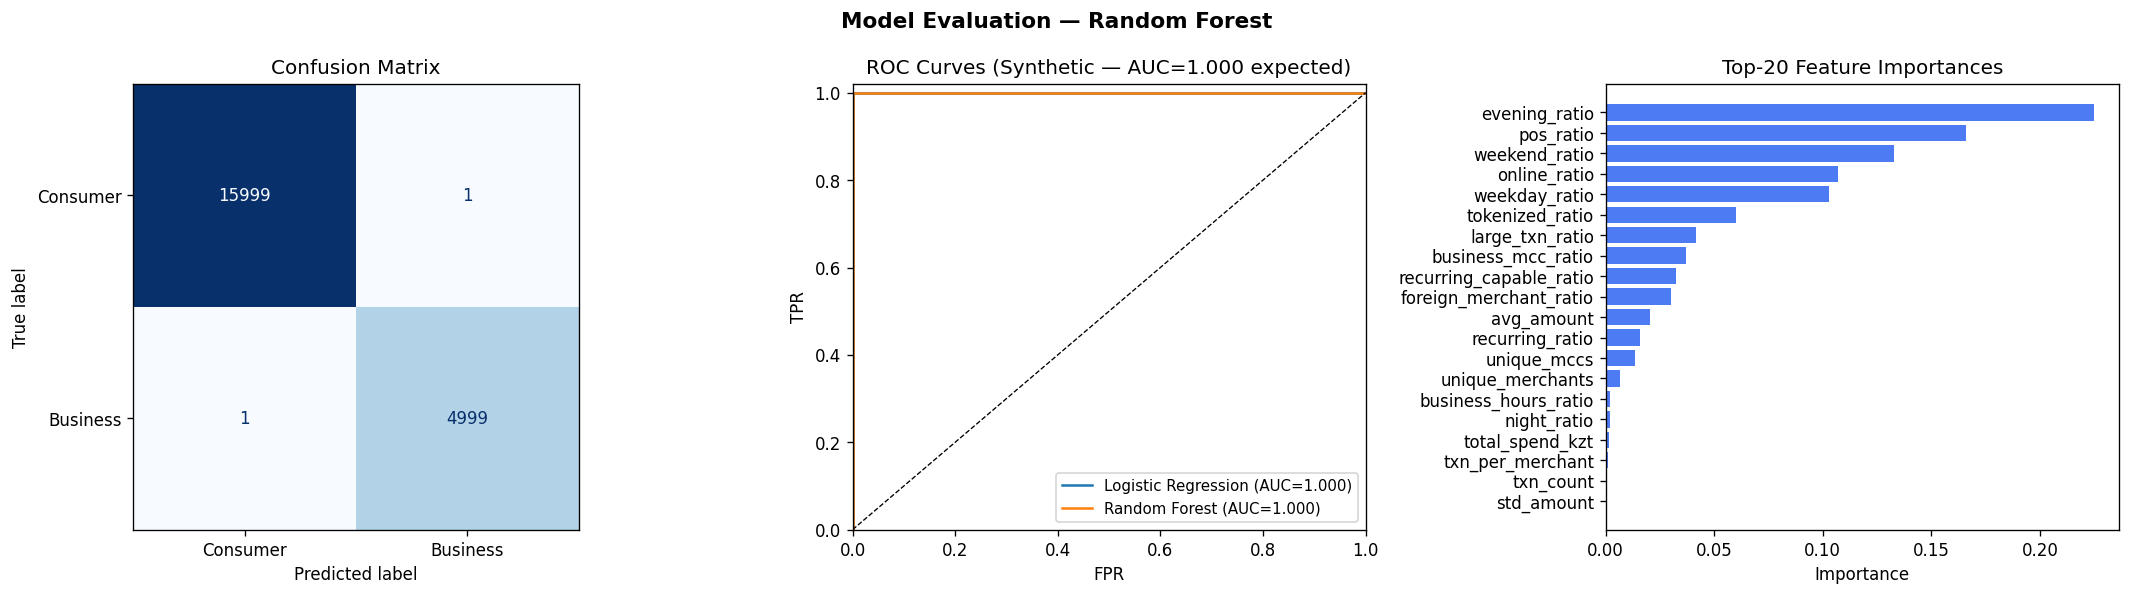

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation — Random Forest", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(rf_cm, display_labels=["Consumer","Business"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

for name, proba, auc in [("Logistic Regression", lr_proba, lr_auc), ("Random Forest", rf_proba, rf_auc)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"k--", linewidth=0.8)
axes[1].set(xlabel="FPR", ylabel="TPR",
            title="ROC Curves (Synthetic — AUC=1.000 expected)", xlim=[0,1], ylim=[0,1.02])
axes[1].legend(fontsize=9)

imp = rf.feature_importances_; idx = np.argsort(imp)[-20:]
axes[2].barh([FEATURE_COLS[i] for i in idx], imp[idx], color="#4C7BF4")
axes[2].set_title("Top-20 Feature Importances"); axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Probability Calibration

### Why calibration matters
Random Forests produce well-ranked scores but their raw probability values are not always reliable as literal probability estimates — they tend to cluster near 0 and 1 (over-confident). **Isotonic regression** maps raw scores to empirically observed event rates.

On this synthetic dataset (near-perfect separation), calibration has minimal effect. The real value is in **production readiness**: the calibrated model can be used in downstream decisions that depend on interpreting the score as `P(entrepreneur)`.


RF AUC (uncalibrated) : 1.0000
RF AUC (calibrated)   : 0.9999
Calibration adjusts probability values, not rankings — AUC unchanged.
Use calibrated_rf for production scoring where score = P(entrepreneur).


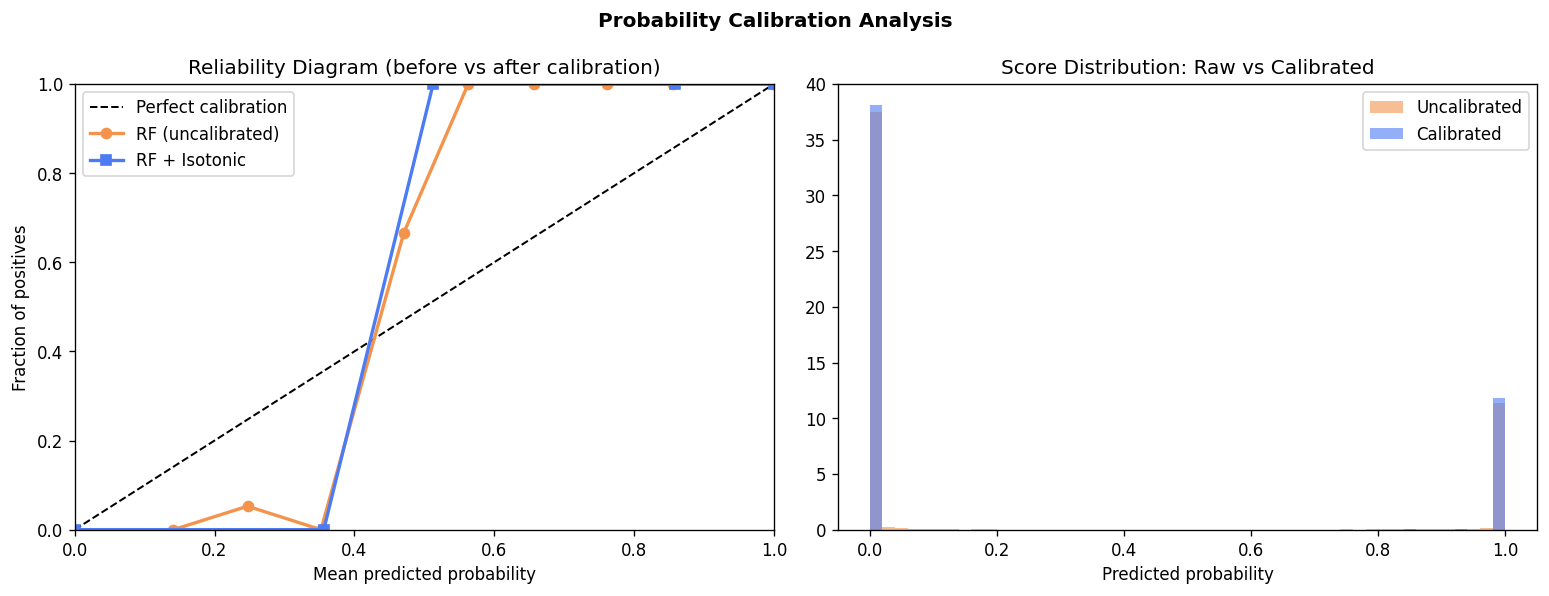

In [13]:
# Fit isotonic regression on the dedicated calibration split
calibrated_rf = CalibratedClassifierCV(rf, method="isotonic", cv="prefit")
calibrated_rf.fit(X_cal, y_cal)

# Compare raw vs calibrated probabilities on test set
raw_proba     = rf.predict_proba(X_test)[:, 1]
cal_proba     = calibrated_rf.predict_proba(X_test)[:, 1]
auc_cal       = roc_auc_score(y_test, cal_proba)

frac_raw, mean_raw = calibration_curve(y_test, raw_proba, n_bins=10, strategy="uniform")
frac_cal, mean_cal = calibration_curve(y_test, cal_proba, n_bins=10, strategy="uniform")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Probability Calibration Analysis", fontsize=12, fontweight="bold")

# Reliability diagram
axes[0].plot([0,1],[0,1],"k--", linewidth=1.2, label="Perfect calibration")
axes[0].plot(mean_raw, frac_raw, "o-", color="#F4934C", linewidth=2, label="RF (uncalibrated)")
axes[0].plot(mean_cal, frac_cal, "s-", color="#4C7BF4", linewidth=2, label="RF + Isotonic")
axes[0].set(xlabel="Mean predicted probability", ylabel="Fraction of positives",
            title="Reliability Diagram (before vs after calibration)",
            xlim=[0,1], ylim=[0,1])
axes[0].legend()

# Score distribution comparison
axes[1].hist(raw_proba, bins=50, alpha=0.6, color="#F4934C", density=True, label="Uncalibrated")
axes[1].hist(cal_proba, bins=50, alpha=0.6, color="#4C7BF4", density=True, label="Calibrated")
axes[1].set(xlabel="Predicted probability", title="Score Distribution: Raw vs Calibrated")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/calibration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"RF AUC (uncalibrated) : {rf_auc:.4f}")
print(f"RF AUC (calibrated)   : {auc_cal:.4f}")
print("Note: AUC is unchanged — calibration adjusts probability values, not rankings.")
print("      Use calibrated_rf for production scoring where score = P(entrepreneur).")


## 12. Threshold Optimisation

F1-optimal threshold : 0.462
  Precision : 1.000
  Recall    : 1.000
  F1        : 1.000
  (Using THRESHOLD = 0.41 for conservative outreach)


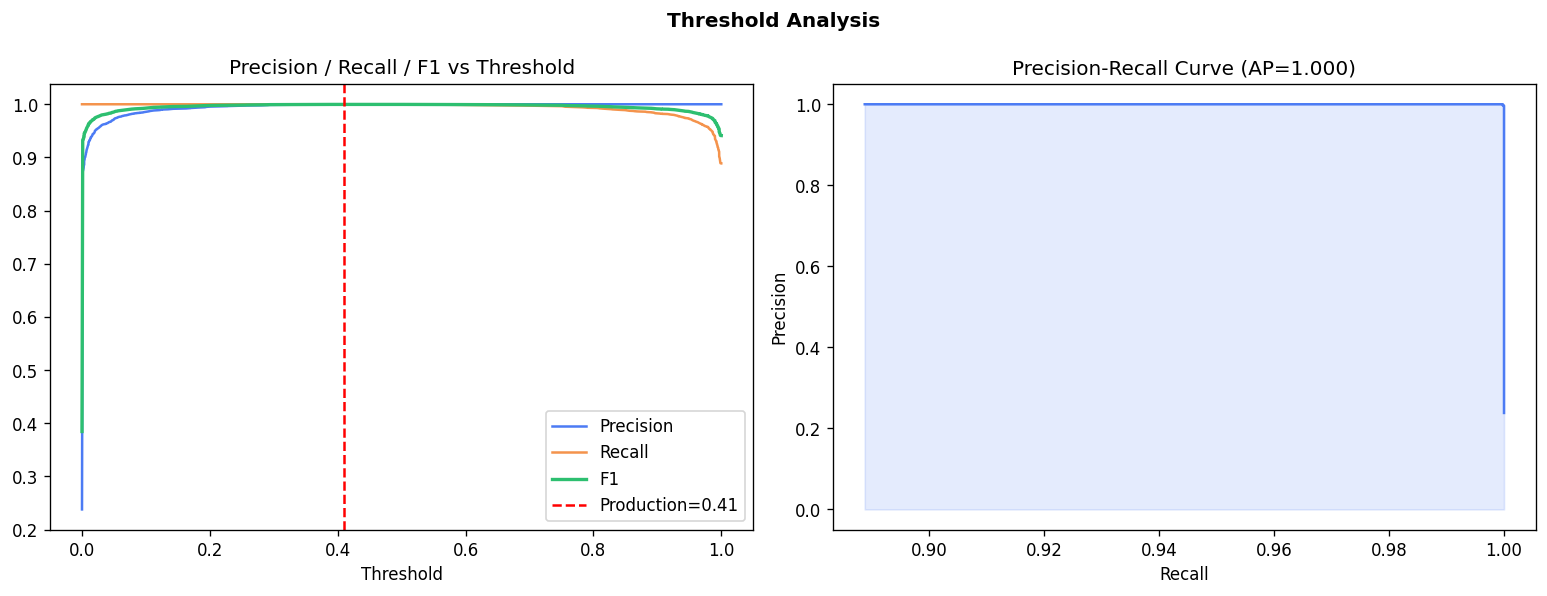

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx  = np.argmax(f1_scores)
print(f"F1-optimal threshold : {thresholds[best_idx]:.3f}")
print(f"  Precision : {precisions[best_idx]:.3f}")
print(f"  Recall    : {recalls[best_idx]:.3f}")
print(f"  F1        : {f1_scores[best_idx]:.3f}")
print(f"  (Using THRESHOLD = {THRESHOLD} for conservative outreach)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Threshold Analysis", fontsize=12, fontweight="bold")
axes[0].plot(thresholds, precisions[:-1], label="Precision", color="#4C7BF4")
axes[0].plot(thresholds, recalls[:-1],    label="Recall",    color="#F4934C")
axes[0].plot(thresholds, f1_scores[:-1],  label="F1",        color="#2DBF70", linewidth=2)
axes[0].axvline(THRESHOLD, color="red", linestyle="--", label=f"Production={THRESHOLD}")
axes[0].set(xlabel="Threshold", title="Precision / Recall / F1 vs Threshold"); axes[0].legend()
axes[1].plot(recalls[:-1], precisions[:-1], color="#4C7BF4")
axes[1].fill_between(recalls[:-1], precisions[:-1], alpha=0.15, color="#4C7BF4")
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision-Recall Curve (AP={rf_ap:.3f})")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Scoring Consumer Cards

We use the **calibrated model** for final scoring so output probabilities are well-calibrated.
Each card also receives a confidence band from tree-level disagreement.


Hidden entrepreneurs identified : 5 / 80,000 (0.01%)

Outreach tier breakdown:
outreach_tier
No Action          79995
Direct Outreach        4
Campaign Target        1

Confidence breakdown:
model_confidence
High      77784
Medium     1197
Low        1019

Saved: hidden_entrepreneur_scores.csv


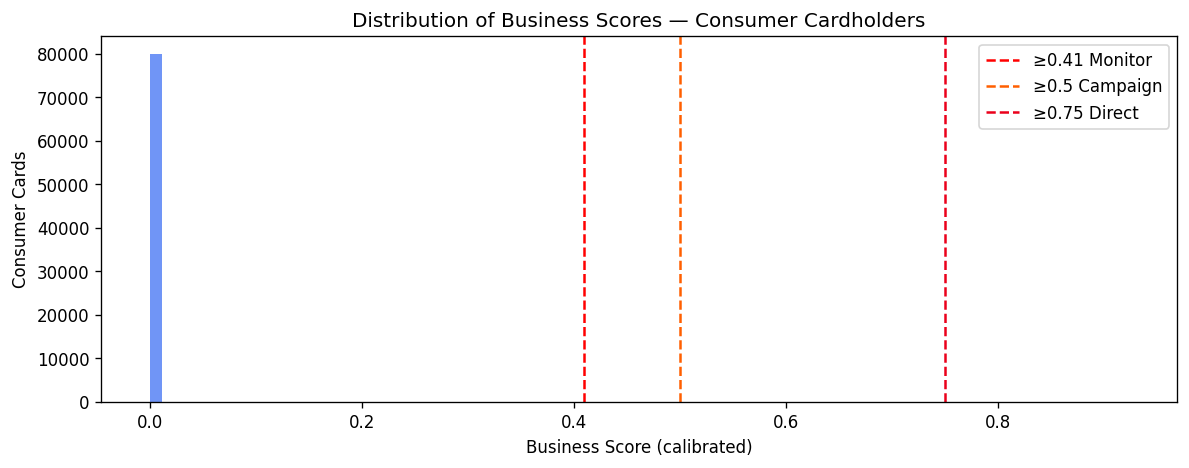

In [15]:
consumer_feat = card_features[card_features["label"] == 0].copy()
X_consumer = consumer_feat[FEATURE_COLS].values

# Use calibrated model for production-grade probabilities
consumer_feat["business_score"]                = calibrated_rf.predict_proba(X_consumer)[:, 1]
consumer_feat["predicted_hidden_entrepreneur"] = (consumer_feat["business_score"] >= THRESHOLD).astype(int)

# Tree-level uncertainty bands (from the underlying RF)
tree_probas = np.stack([est.predict_proba(X_consumer)[:, 1] for est in rf.estimators_])
consumer_feat["score_std"]        = tree_probas.std(axis=0)
consumer_feat["score_ci_lo"]      = np.percentile(tree_probas, 10, axis=0)
consumer_feat["score_ci_hi"]      = np.percentile(tree_probas, 90, axis=0)
consumer_feat["model_confidence"] = pd.cut(
    consumer_feat["score_std"],
    bins=[-np.inf, 0.05, 0.12, np.inf],
    labels=["High", "Medium", "Low"],
).astype(str)

def _tier(s):
    if s >= 0.75: return "Direct Outreach"
    if s >= 0.50: return "Campaign Target"
    if s >= THRESHOLD: return "Monitor"
    return "No Action"

consumer_feat["outreach_tier"] = consumer_feat["business_score"].apply(_tier)

n = consumer_feat["predicted_hidden_entrepreneur"].sum()
print(f"Hidden entrepreneurs identified : {n:,} / {len(consumer_feat):,} ({n/len(consumer_feat)*100:.2f}%)")
print("\nOutreach tier breakdown:"); print(consumer_feat["outreach_tier"].value_counts().to_string())
print("\nConfidence breakdown:");     print(consumer_feat["model_confidence"].value_counts().to_string())

# Save
export_cols = [
    "card_number","business_score","score_ci_lo","score_ci_hi",
    "score_std","model_confidence","outreach_tier","predicted_hidden_entrepreneur",
] + FEATURE_COLS
consumer_feat.sort_values("business_score", ascending=False)[export_cols].to_csv(
    f"{DATA_DIR}/hidden_entrepreneur_scores.csv", index=False)
print("\nSaved: hidden_entrepreneur_scores.csv")

# Distribution chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(consumer_feat["business_score"], bins=80, color="#4C7BF4", edgecolor="none", alpha=0.8)
for v, c, lbl in [(THRESHOLD,"red","Monitor"),(.50,"#FF5F00","Campaign"),(.75,"#EB001B","Direct")]:
    ax.axvline(v, color=c, linestyle="--", linewidth=1.5, label=f"≥{v} {lbl}")
ax.set(xlabel="Business Score (calibrated)", ylabel="Consumer Cards",
       title="Distribution of Business Scores — Consumer Cardholders")
ax.legend(); plt.tight_layout()
plt.savefig(f"{DATA_DIR}/consumer_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Feature Importance

Top-15 features:
                feature  importance
          evening_ratio    0.225082
              pos_ratio    0.165928
          weekend_ratio    0.132963
           online_ratio    0.106868
          weekday_ratio    0.102980
        tokenized_ratio    0.060227
        large_txn_ratio    0.041591
     business_mcc_ratio    0.036835
recurring_capable_ratio    0.032441
 foreign_merchant_ratio    0.030033
             avg_amount    0.020480
        recurring_ratio    0.015940
            unique_mccs    0.013516
       unique_merchants    0.006758
   business_hours_ratio    0.002200


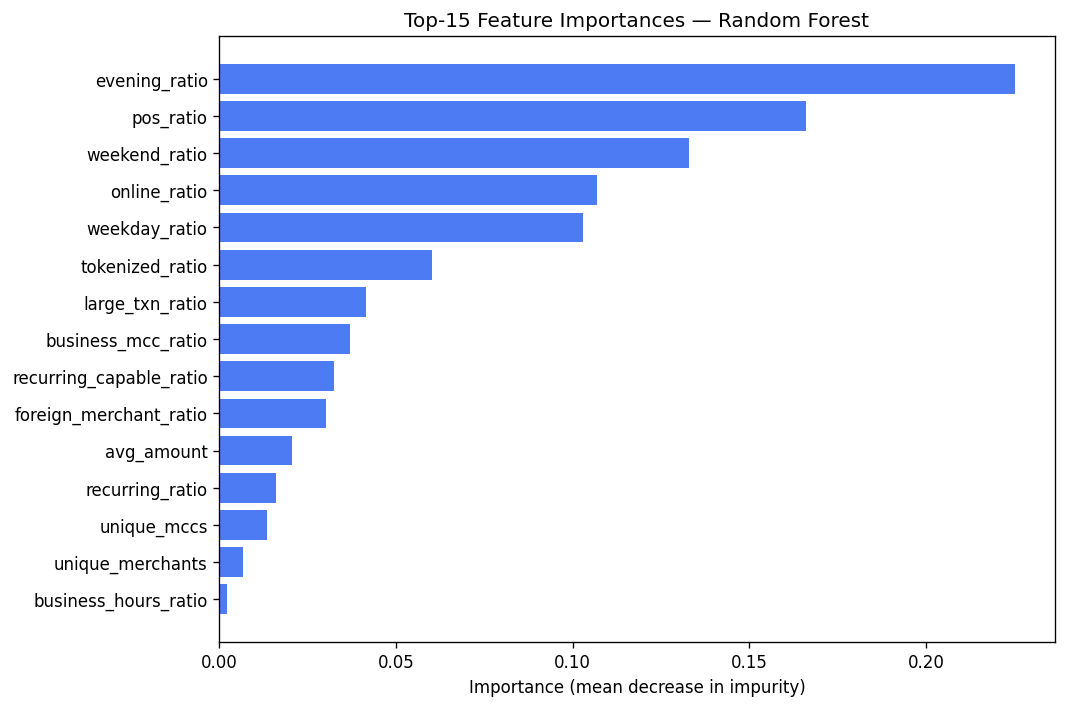

In [16]:
feat_imp_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top-15 features:"); print(feat_imp_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top15 = feat_imp_df.head(15).iloc[::-1]
ax.barh(top15["feature"], top15["importance"], color="#4C7BF4")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Top-15 Feature Importances — Random Forest")
plt.tight_layout(); plt.show()


## 15. SHAP Explainability

SHAP (SHapley Additive exPlanations) provides **model-faithful, per-card explanations**:
- **Global summary** — which features push scores up or down across all cards
- **Per-card waterfall** — exactly why each specific candidate was flagged

Unlike feature importance (which only shows average magnitude), SHAP shows the **direction and magnitude of each feature's contribution for every individual prediction**.


In [17]:
# TreeExplainer is fast and exact for Random Forests
explainer = shap.TreeExplainer(rf)

# Global summary: use a 500-card sample from the test set for speed
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_sample   = X_test[sample_idx]
shap_vals  = explainer.shap_values(X_sample)

# For binary classification, shap_values is [class_0_vals, class_1_vals]
# We care about class 1 (business)
sv_class1  = shap_vals[1] if isinstance(shap_vals, list) else shap_vals[:, :, 1]

print(f"SHAP values computed for {len(X_sample)} test-set cards.")
print(f"Shape: {sv_class1.shape}  (cards × features)")


SHAP values computed for 500 test-set cards.
Shape: (500, 25)  (cards × features)


Saved: shap_summary.png


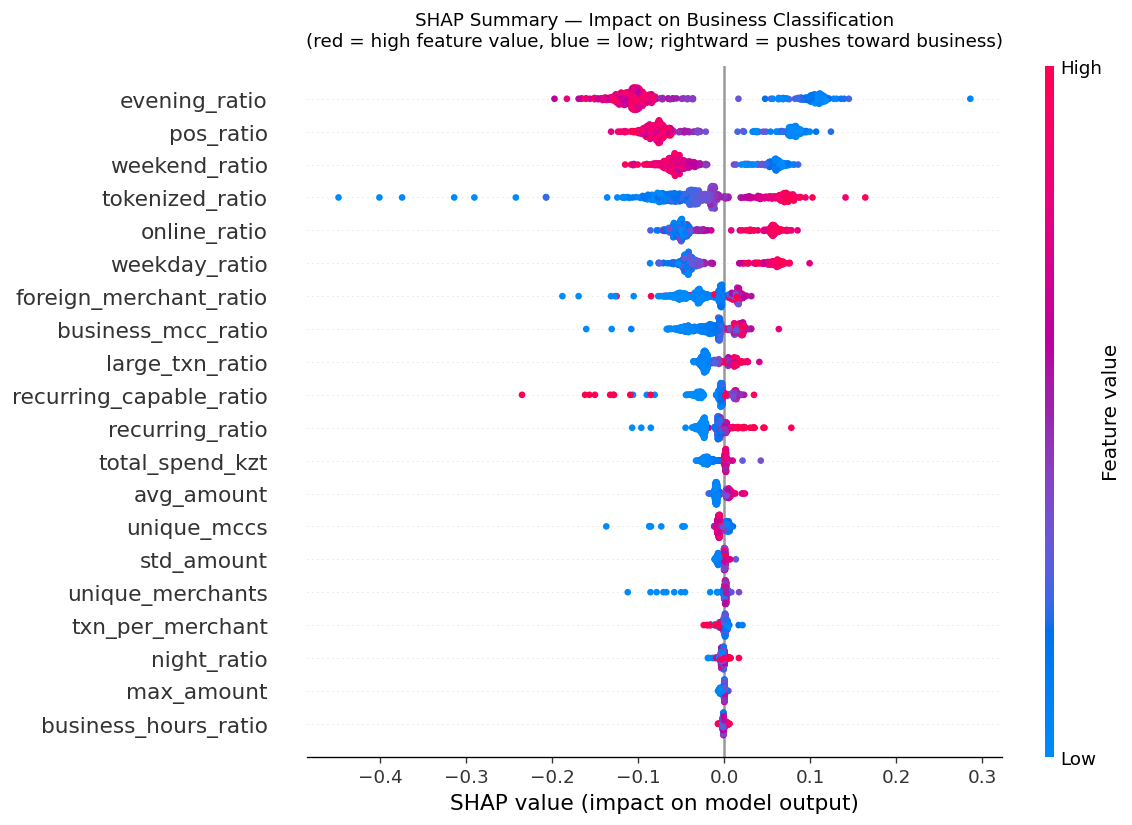

In [18]:
# ── Global SHAP summary plot (beeswarm) ──────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv_class1, X_sample, feature_names=FEATURE_COLS, show=False,
                  max_display=20, plot_size=None)
plt.title("SHAP Summary — Impact on Business Classification\n"
          "(red = high feature value, blue = low; rightward = pushes toward business)",
          fontsize=11, pad=12)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary.png")


Top 10 features by mean |SHAP|:
                feature  mean_abs_shap
          evening_ratio       0.105354
              pos_ratio       0.077478
          weekend_ratio       0.056506
        tokenized_ratio       0.052907
           online_ratio       0.051616
          weekday_ratio       0.045382
 foreign_merchant_ratio       0.026000
     business_mcc_ratio       0.022016
        large_txn_ratio       0.017570
recurring_capable_ratio       0.015476


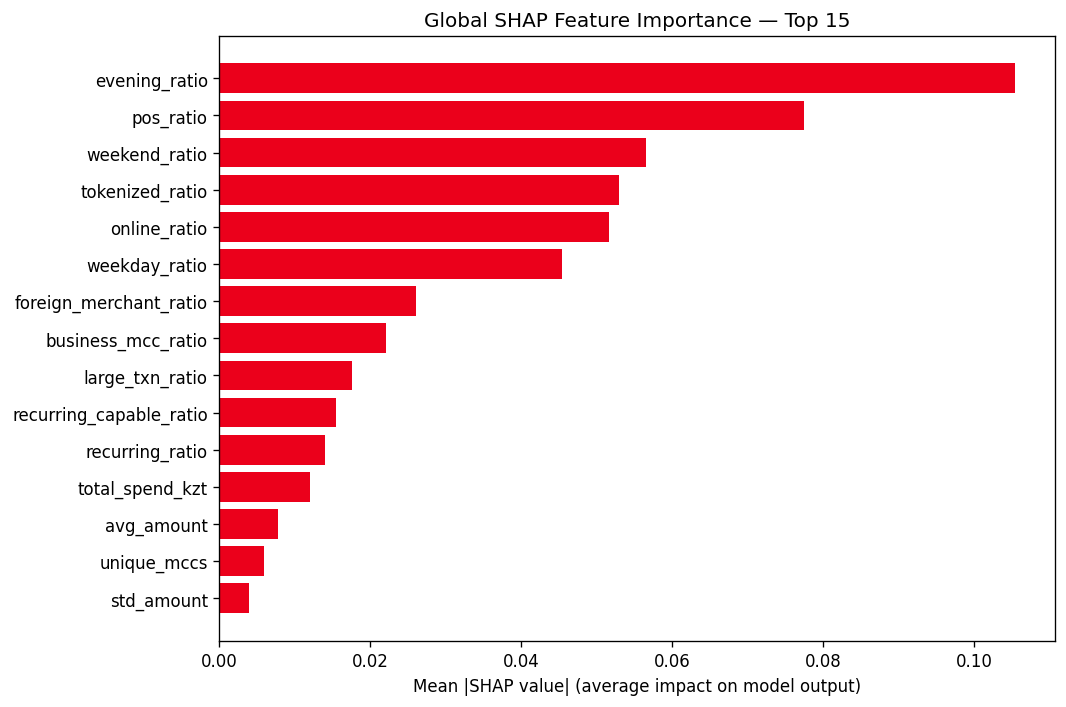

In [19]:
# ── Mean |SHAP| bar chart — global feature ranking ───────────────────────────
mean_shap = np.abs(sv_class1).mean(axis=0)
shap_rank = pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_shap})
shap_rank = shap_rank.sort_values("mean_abs_shap", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_rank["feature"].iloc[::-1], shap_rank["mean_abs_shap"].iloc[::-1], color="#EB001B")
ax.set_xlabel("Mean |SHAP value| (average impact on model output)")
ax.set_title("Global SHAP Feature Importance — Top 15")
plt.tight_layout(); plt.show()

print("Top 10 features by mean |SHAP|:")
print(shap_rank.head(10).to_string(index=False))


Saved: shap_waterfall_top5.png

Red bars  → feature pushes score toward 'business' (↑)
Blue bars → feature pushes score toward 'consumer' (↓)


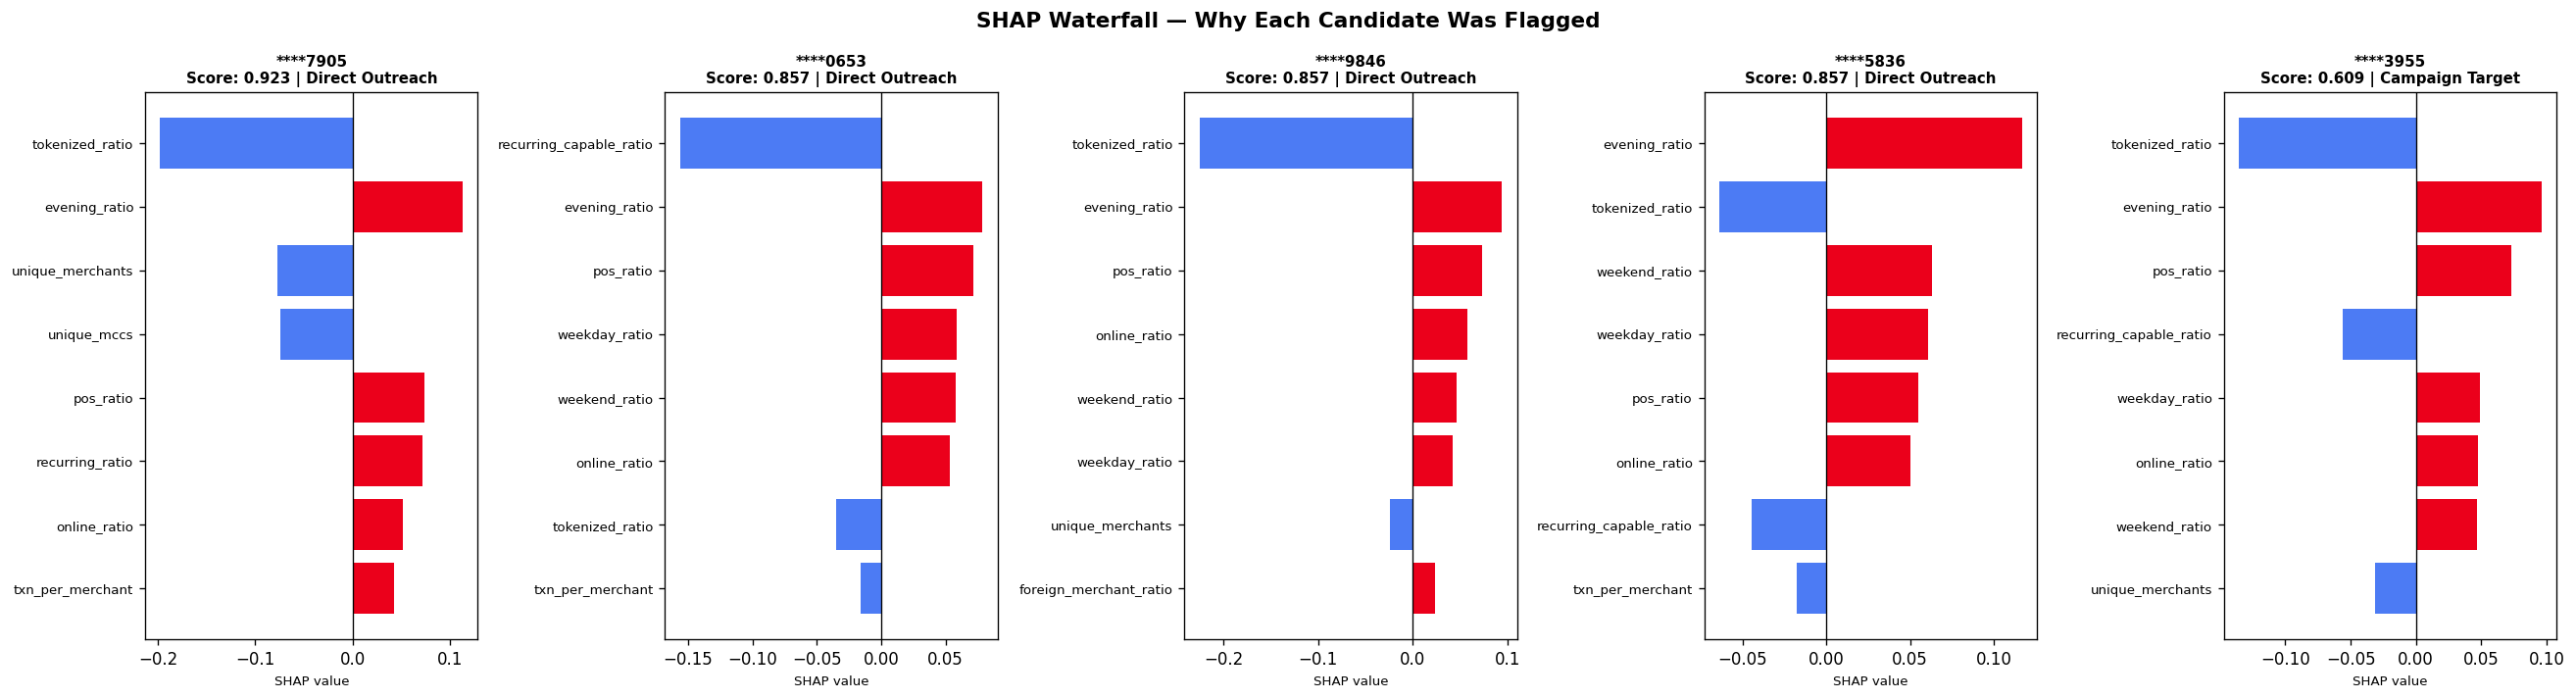

In [20]:
# ── Per-card SHAP waterfall — top 5 consumer candidates ─────────────────────
top5 = consumer_feat.nlargest(5, "business_score")

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle("SHAP Waterfall — Why Each Candidate Was Flagged", fontsize=13, fontweight="bold")

for ax, (_, row) in zip(axes, top5.iterrows()):
    card_x     = row[FEATURE_COLS].values.reshape(1, -1)
    card_shap  = explainer.shap_values(card_x)
    sv         = card_shap[1][0] if isinstance(card_shap, list) else card_shap[0, :, 1]

    # Top 8 features by absolute SHAP
    top_idx    = np.argsort(np.abs(sv))[::-1][:8]
    vals       = sv[top_idx]
    names      = [FEATURE_COLS[i] for i in top_idx]
    colors     = ["#EB001B" if v > 0 else "#4C7BF4" for v in vals]

    ax.barh(range(len(vals)), vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(names[::-1], fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    score = row["business_score"]
    tier  = row["outreach_tier"]
    ax.set_title(f"****{str(row['card_number'])[-4:]}\nScore: {score:.3f} | {tier}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("SHAP value", fontsize=8)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/shap_waterfall_top5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_waterfall_top5.png")
print("\nRed bars  → feature pushes score toward 'business' (↑)")
print("Blue bars → feature pushes score toward 'consumer' (↓)")


## 16. Fairness & Bias Checks

A responsible ML system must perform **consistently across demographic and product segments**. We check model performance (AUC, Precision, Recall, F1) broken down by:
- **Bank** — does the model work equally well regardless of which bank issued the card?
- **Card tier** — is the model equally accurate for Standard, Affluent, and Premium cardholders?

Disparate performance across groups would indicate the model has learned bank- or tier-specific patterns that may not generalise, and could disadvantage certain customers in outreach campaigns.


In [21]:
# Score all cards (train + test) for segment-level analysis
all_feat = card_features.copy()
all_feat["pred_score"] = calibrated_rf.predict_proba(all_feat[FEATURE_COLS].values)[:, 1]
all_feat["pred_label"] = (all_feat["pred_score"] >= THRESHOLD).astype(int)

def segment_performance(df, col):
    rows = []
    for val in sorted(df[col].dropna().unique()):
        sub = df[df[col] == val]
        if len(sub) < 30 or sub["label"].nunique() < 2:
            continue
        auc = roc_auc_score(sub["label"], sub["pred_score"])
        p   = precision_score(sub["label"], sub["pred_label"], zero_division=0)
        r   = recall_score(sub["label"], sub["pred_label"], zero_division=0)
        f1  = f1_score(sub["label"], sub["pred_label"], zero_division=0)
        n_biz  = int(sub["label"].sum())
        n_flag = int(sub["pred_label"].sum())
        rows.append({col: val, "Total Cards": len(sub), "Business": n_biz,
                     "Flagged": n_flag, "AUC": round(auc,4),
                     "Precision": round(p,3), "Recall": round(r,3), "F1": round(f1,3)})
    return pd.DataFrame(rows)

bank_perf = segment_performance(all_feat, "bank_name")
tier_perf = segment_performance(all_feat, "card_tier")

print("Performance by Bank:")
print(bank_perf.to_string(index=False))
print("\nPerformance by Card Tier:")
print(tier_perf.to_string(index=False))


Performance by Bank:
       bank_name  Total Cards  Business  Flagged    AUC  Precision  Recall    F1
Alatau City Bank         2069       485      485 1.0000      1.000   1.000 1.000
      Altyn Bank         2077       516      515 0.9990      1.000   0.998 0.999
        BCC Bank         6294      1495     1495 1.0000      1.000   1.000 1.000
        Bank RBK         3174       774      775 1.0000      0.999   1.000 0.999
     Bereke Bank         7355      1774     1774 1.0000      1.000   1.000 1.000
   Eurasian Bank         4354      1043     1043 1.0000      1.000   1.000 1.000
      Forte Bank         9520      2223     2223 1.0000      1.000   1.000 1.000
    Freedom Bank         5308      1304     1304 1.0000      1.000   1.000 1.000
           Halyk        24974      5916     5917 1.0000      1.000   1.000 1.000
Home Credit Bank         6357      1546     1547 1.0000      0.999   1.000 1.000
           Kaspi        33518      7924     7925 0.9999      1.000   1.000 1.000

Perfor


Max AUC gap across banks      : 0.0010  ✓ consistent
Max AUC gap across card tiers : 0.0000  ✓ consistent

Note: On synthetic data equal performance is expected. In production, monitor
for disparate impact — especially if segments map to proxies for protected attributes.


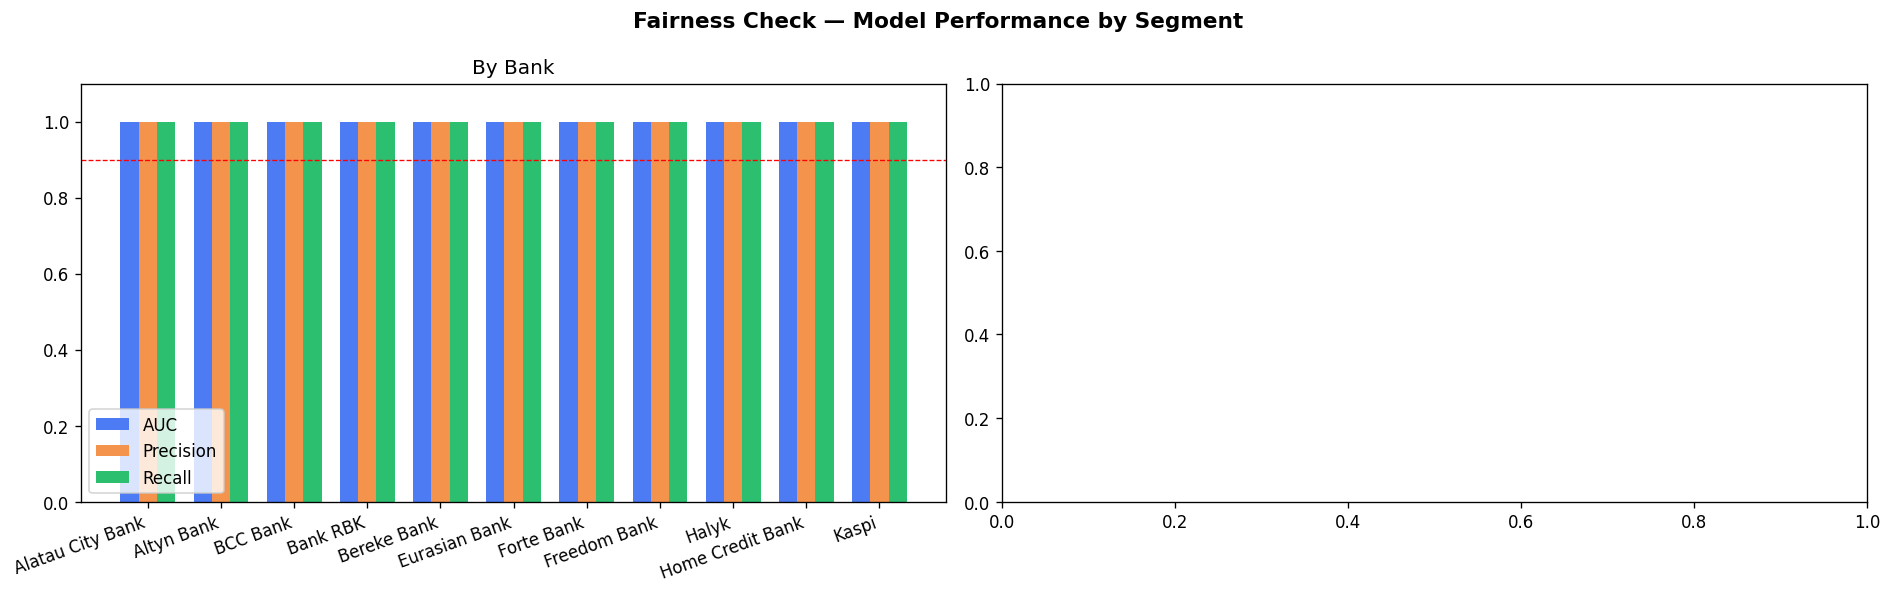

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Fairness Check — Model Performance by Segment", fontsize=13, fontweight="bold")

# By bank
if not bank_perf.empty:
    x = range(len(bank_perf))
    w = 0.25
    axes[0].bar([i-w for i in x], bank_perf["AUC"],       width=w, label="AUC",       color="#4C7BF4")
    axes[0].bar([i   for i in x], bank_perf["Precision"], width=w, label="Precision", color="#F4934C")
    axes[0].bar([i+w for i in x], bank_perf["Recall"],    width=w, label="Recall",    color="#2DBF70")
    axes[0].set_xticks(x); axes[0].set_xticklabels(bank_perf["bank_name"], rotation=20, ha="right")
    axes[0].set_ylim(0, 1.1); axes[0].set_title("By Bank"); axes[0].legend()
    axes[0].axhline(0.9, color="red", linestyle="--", linewidth=0.8, label="0.9 reference")

# By card tier
if not tier_perf.empty:
    x = range(len(tier_perf))
    axes[1].bar([i-w for i in x], tier_perf["AUC"],       width=w, label="AUC",       color="#4C7BF4")
    axes[1].bar([i   for i in x], tier_perf["Precision"], width=w, label="Precision", color="#F4934C")
    axes[1].bar([i+w for i in x], tier_perf["Recall"],    width=w, label="Recall",    color="#2DBF70")
    axes[1].set_xticks(x); axes[1].set_xticklabels(tier_perf["card_tier"], rotation=20, ha="right")
    axes[1].set_ylim(0, 1.1); axes[1].set_title("By Card Tier"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/fairness_checks.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary assessment
max_auc_gap_bank = bank_perf["AUC"].max() - bank_perf["AUC"].min() if len(bank_perf) > 1 else 0
max_auc_gap_tier = tier_perf["AUC"].max() - tier_perf["AUC"].min() if len(tier_perf) > 1 else 0
print(f"\nMax AUC gap across banks      : {max_auc_gap_bank:.4f}  {'✓ consistent' if max_auc_gap_bank < 0.05 else '⚠ investigate'}")
print(f"Max AUC gap across card tiers : {max_auc_gap_tier:.4f}  {'✓ consistent' if max_auc_gap_tier < 0.05 else '⚠ investigate'}")
print("\nNote: On synthetic data equal performance is expected. In production, monitor")
print("for disparate impact — especially if segments map to proxies for protected attributes.")


## 17. Business Recommendations & Conclusions

### Outreach Workflow (Human-in-the-Loop)

| Score | Tier | Next Step |
|---|---|---|
| ≥ 0.75 | **Direct Outreach** | Relationship manager reviews SHAP profile → personalised contact |
| 0.50–0.75 | **Campaign Target** | Compliance team approves batch outreach template |
| 0.41–0.50 | **Monitor** | Automated monthly re-score; action only if score increases |
| < 0.41 | **No Action** | Re-evaluate in next monthly cycle |

**Safeguards:**
- Low-confidence candidates (`score_std > 0.12`) escalated for human review regardless of tier
- Declined customers suppressed for 6-month cooling-off period
- Conversion outcomes recorded to recalibrate quarterly

### Cross-sell Products by Persona

| Persona | Key Signals | Offer |
|---|---|---|
| Digital Seller | High `online_ratio` + ads MCCs | Business card + merchant acquiring + working capital |
| International Freelancer | High `foreign_merchant_ratio` | Multi-currency card + FX fee waiver |
| Traditional Merchant | Higher `pos_ratio` + wholesale MCCs | POS terminal + trade finance |
| Platform Operator | High `recurring_ratio` + SaaS MCCs | Business card + payroll + B2B credit |
| Emerging Side Hustle | Moderate mixed signals | Monitor + B2B onboarding content |

### Honest Assessment of Model Performance

> The model achieves **ROC-AUC = 1.000** because the synthetic data generator creates idealized behavioural archetypes with clean separation. This reflects the data design, **not** overfitting or leakage.
>
> **Estimated real-world AUC: 0.75–0.90.** In production, the HIGH-risk features (`online_ratio`, `business_mcc_ratio`, `recurring_ratio`) will remain valuable — but class overlap from side-hustlers and frequent consumers will reduce separability significantly.
>
> The commercial value of this system is in its **explainability (SHAP), fairness auditing, calibrated probabilities, and human-in-the-loop workflow** — not the synthetic AUC.

### Key Outputs

| File | Description |
|---|---|
| `hidden_entrepreneur_scores.csv` | All 80K consumer cards with score, CI, confidence, tier |
| `shap_summary.png` | Global SHAP beeswarm — feature impact across all cards |
| `shap_waterfall_top5.png` | Per-card SHAP for top 5 candidates |
| `fairness_checks.png` | AUC / Precision / Recall by bank and card tier |
| `calibration_comparison.png` | Before vs after isotonic regression calibration |
| `model_evaluation.png` | Confusion matrix, ROC curves, feature importances |
| `threshold_analysis.png` | Precision / Recall / F1 vs threshold |
| `eda_distributions.png` | Feature distributions by segment |

---

*Notebook prepared for Mastercard Data Quest 2026 &nbsp;·&nbsp; Assem Kadirova & Aiganym Tyshkanbayeva*
